In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [55]:
import pandas as pd

file_path = '/content/drive/MyDrive/Pós-Unipds/dataframes/modulo01/clientes_base.csv'

df = pd.read_csv(file_path)

print('Primeiras 5 linhas do DataFrame:')
display(df.head())

print('\nDataFrame info (column type and non-null counts):')
df.info()

Primeiras 5 linhas do DataFrame:


,cliente_id,idade,plano,ciclo,valor_mensal,regiao,canal_aquisicao,nps,data_assinatura,data_cancelamento,data_ultimo_acesso,data_extracao,dias_ativos_ult_mes,horas_assistidas_total,motivo_cancelamento,churn
0,5746,36,BASICO,Anual,19.9,Sudeste,Indicacao,6,2023-04-11,NaN,2024-01-29,2024-01-31,15,276.0,NaN,0
1,4100,48,Padrão,Mensal,34.9,Sudeste,orgânico,8,2022-06-02,NaN,2024-01-30,2024-01-31,14,394.9,NaN,0
2,4690,48,Premium,Mensal,55.9,Nordeste,orgânico,4,2021-03-20,2022-11-17,2022-10-31,2024-01-31,5,257.0,PREÇO,1
3,3454,46,BASICO,Anual,1990.0,Sul,Google,10,2023-04-02,NaN,2024-01-13,2024-01-31,19,385.0,NaN,0
4,1437,46,Basico,Mensal,19.9,Norte,indicação,8,2023-04-21,NaN,2024-01-16,2024-01-31,11,205.3,NaN,0



DataFrame info (column type and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cliente_id              5025 non-null   int64  
 1   idade                   5025 non-null   int64  
 2   plano                   5025 non-null   object 
 3   ciclo                   5025 non-null   object 
 4   valor_mensal            5025 non-null   float64
 5   regiao                  5025 non-null   object 
 6   canal_aquisicao         5025 non-null   object 
 7   nps                     5025 non-null   int64  
 8   data_assinatura         5025 non-null   object 
 9   data_cancelamento       1516 non-null   object 
 10  data_ultimo_acesso      4975 non-null   object 
 11  data_extracao           5025 non-null   object 
 12  dias_ativos_ult_mes     5025 non-null   int64  
 13  horas_assistidas_total  5025 non-null   fl

Ao observar os tipos de dados deste DataFrame, nota-se que as colunas `data_assinatura`, `data_cancelamento`, `data_ultimo_acesso` e `data_extracao` foram inferidas como tipo `Object`. Contudo, para análises temporais corretas, essas colunas deveriam ser do tipo `DateTime`. Se não convertidas, as datas serão tratadas como strings, o que pode comprometer a precisão das operações e análises baseadas em tempo.

### Análise de Colunas Categóricas



--- Análise da coluna: 'plano' ---
Valores únicos e suas contagens:
plano
Basico     708
BASICO     677
básico     677
Padrao     665
Padrão     654
padrão     646
premium    513
Premium    485
Name: count, dtype: int64


/tmp/ipykernel_1105/3482227347.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')


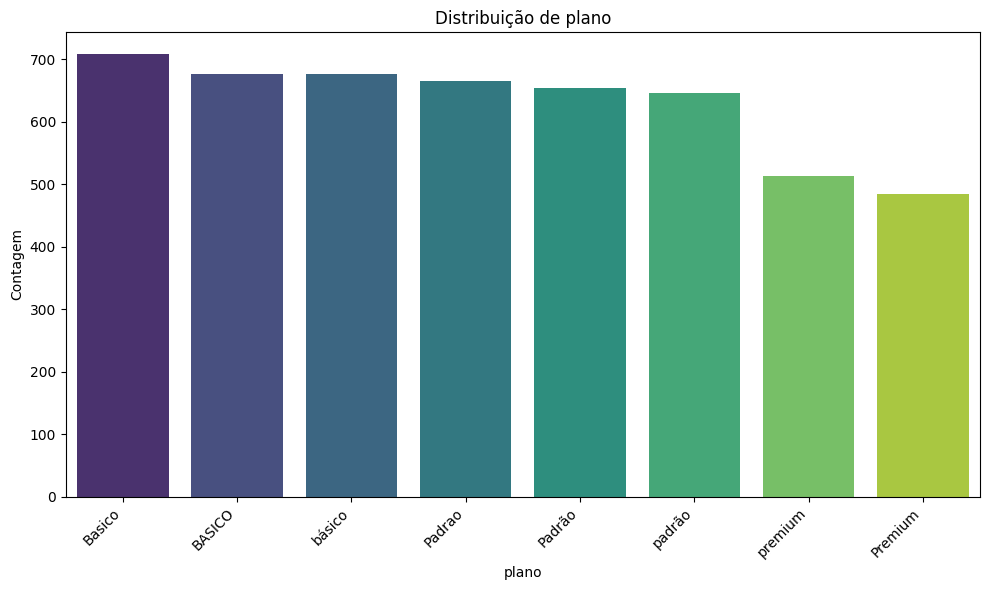

/tmp/ipykernel_1105/3482227347.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')



--- Análise da coluna: 'ciclo' ---
Valores únicos e suas contagens:
ciclo
Mensal    3794
Anual     1231
Name: count, dtype: int64


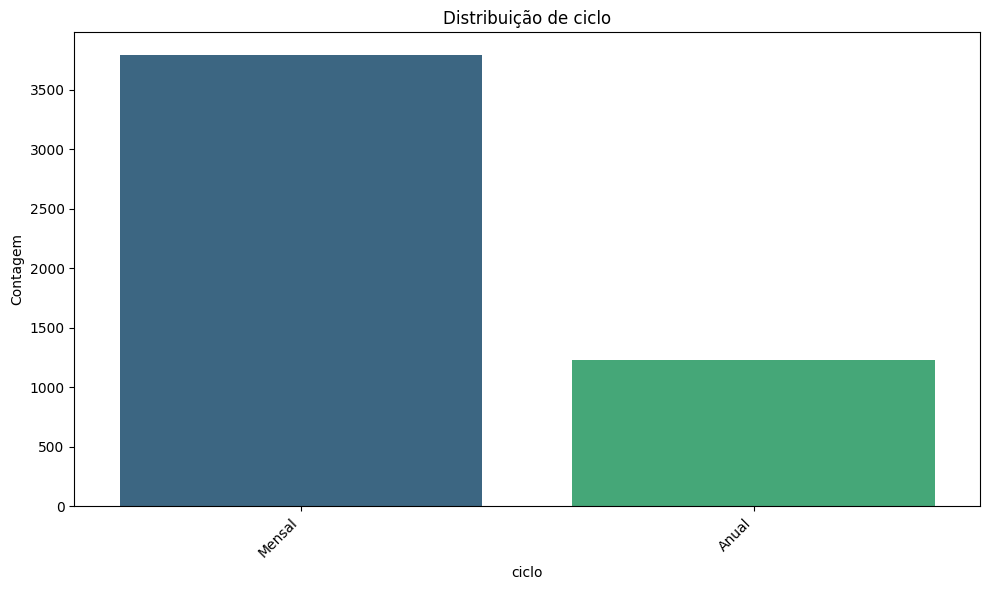


--- Análise da coluna: 'regiao' ---
Valores únicos e suas contagens:
regiao
Sudeste         2057
Nordeste         964
Sul              938
Centro-Oeste     488
Norte            408
?                170
Name: count, dtype: int64


/tmp/ipykernel_1105/3482227347.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')


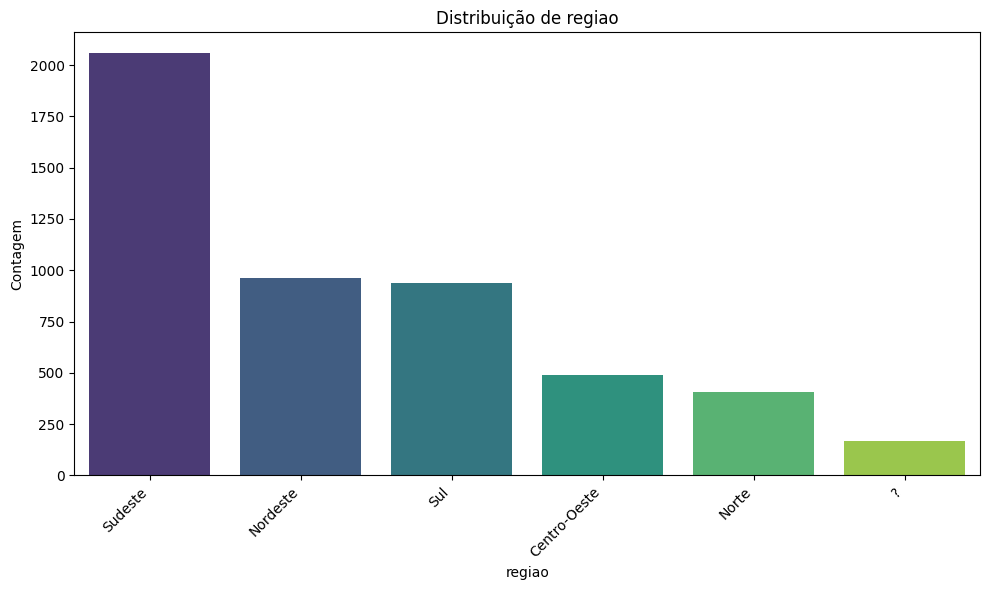


--- Análise da coluna: 'canal_aquisicao' ---
Valores únicos e suas contagens:
canal_aquisicao
Organico     781
orgânico     729
Indicacao    556
IG           529
indicação    526
Instagram    519
instagram    499
Google       452
google       434
Name: count, dtype: int64


/tmp/ipykernel_1105/3482227347.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')


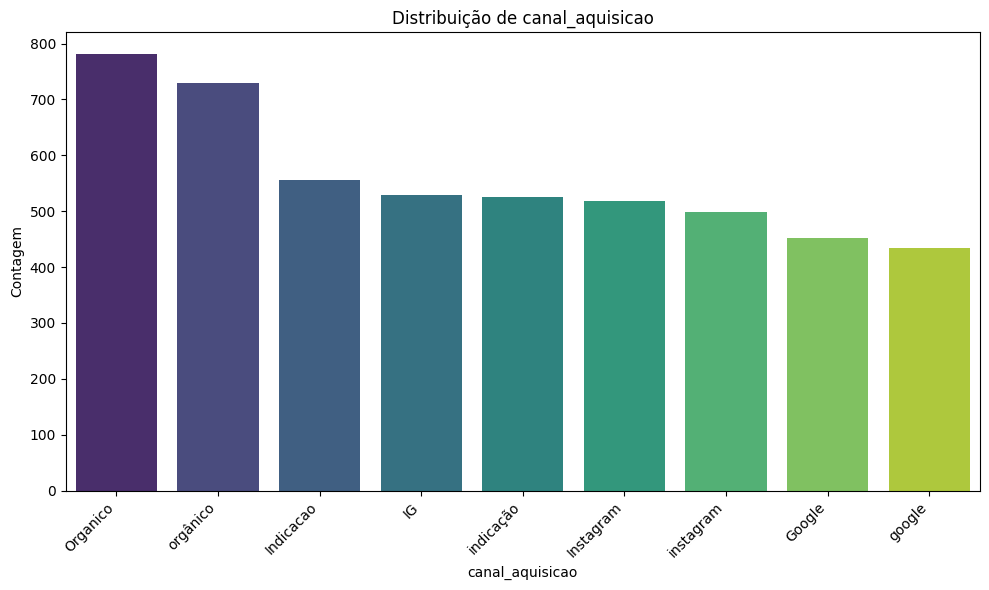

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['plano', 'ciclo', 'regiao', 'canal_aquisicao']

for col in categorical_cols:
    print(f"\n--- Análise da coluna: '{col}' ---")

    # Get unique values and their counts
    value_counts = df[col].value_counts()
    print("Valores únicos e suas contagens:")
    print(value_counts)

    # Generate bar plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Contagem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Análise de Nulos e Limpeza de Dados

In [57]:
# 1. Quantidade de valores nulos por coluna
print('Quantidade de valores nulos por coluna:')
display(df.isnull().sum())

Quantidade de valores nulos por coluna:


,0
cliente_id,0
idade,0
plano,0
ciclo,0
valor_mensal,0
regiao,0
canal_aquisicao,0
nps,0
data_assinatura,0
data_cancelamento,3509


In [ ]:
# 2. Exemplo de DataFrame quando a coluna 'regiao' é '?'
print("Exemplos onde a coluna 'regiao' é '?':")
display(df[df['regiao'] == '?'].head())

Exemplos onde a coluna 'regiao' é '?':


,cliente_id,idade,plano,ciclo,valor_mensal,regiao,canal_aquisicao,nps,data_assinatura,data_cancelamento,data_ultimo_acesso,data_extracao,dias_ativos_ult_mes,horas_assistidas_total,motivo_cancelamento,churn
6,4918,37,Basico,Mensal,19.9,?,instagram,4,2023-10-12,2023-12-28,2023-12-09,2024-01-31,5,29.6,problema tecnico,1
10,4356,30,básico,Mensal,19.9,?,Organico,8,2020-12-22,NaN,2024-01-11,2024-01-31,15,900.0,NaN,0
34,1433,56,Padrão,Anual,3490.0,?,orgânico,9,2023-04-14,NaN,2024-01-22,2024-01-31,11,180.4,NaN,0
68,5259,41,padrão,Mensal,34.9,?,google,5,2023-05-03,NaN,2024-01-28,2024-01-31,8,139.9,NaN,0
135,2171,42,Padrão,Mensal,3490.0,?,orgânico,10,2021-04-16,NaN,2024-01-06,2024-01-31,10,505.2,NaN,0


In [ ]:
# 3. Substituir valores na coluna 'plano'
# Primeiramente, converter para minúsculas para padronizar
df['plano'] = df['plano'].str.lower()

# Realizar as substituições
df['plano'] = df['plano'].replace({
    'basico': 'básico',
    'padrao': 'padrão',
    'premium': 'premium' # Mantém premium como está, apenas para garantir padronização de case
})

print("Valores únicos da coluna 'plano' após a padronização:")
display(df['plano'].value_counts())

Valores únicos da coluna 'plano' após a padronização:


,count
plano,
básico,2062
padrão,1965
premium,998


In [ ]:
# 4. Substituir valores na coluna 'canal_aquisicao'
# Primeiramente, converter para minúsculas para padronizar
df['canal_aquisicao'] = df['canal_aquisicao'].str.lower()

# Realizar as substituições
df['canal_aquisicao'] = df['canal_aquisicao'].replace({
    'organico': 'orgânico',
    'indicacao': 'indicação',
    'ig': 'instagram',
    'instagram': 'instagram',
    'google': 'google'
})

print("Valores únicos da coluna 'canal_aquisicao' após a padronização:")
display(df['canal_aquisicao'].value_counts())

Valores únicos da coluna 'canal_aquisicao' após a padronização:


,count
canal_aquisicao,
instagram,1547
orgânico,1510
indicação,1082
google,886


### Tratamento de Valores '?'

In [58]:
import numpy as np

# Substituir '?' por NaN em todo o DataFrame
df = df.replace('?', np.nan)

print("Quantidade de valores nulos por coluna após a substituição de '?':")
display(df.isnull().sum())

Quantidade de valores nulos por coluna após a substituição de '?':


,0
cliente_id,0
idade,0
plano,0
ciclo,0
valor_mensal,0
regiao,170
canal_aquisicao,0
nps,0
data_assinatura,0
data_cancelamento,3509


### Conversão de Colunas de Data para Datetime

In [59]:
# Lista de colunas que parecem ser datas (from previous context, already converted 'data_assinatura', 'data_cancelamento', 'data_ultimo_acesso', 'data_extracao')
# Re-running the conversion to ensure consistency if the cell was deleted.
date_columns = ['data_assinatura', 'data_cancelamento', 'data_ultimo_acesso', 'data_extracao']

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"Coluna '{col}' convertida para datetime.")

print('\nDataFrame Info (tipos de coluna atualizados):')
df.info()

Coluna 'data_assinatura' convertida para datetime.
Coluna 'data_cancelamento' convertida para datetime.
Coluna 'data_ultimo_acesso' convertida para datetime.
Coluna 'data_extracao' convertida para datetime.

DataFrame Info (tipos de coluna atualizados):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   cliente_id              5025 non-null   int64         
 1   idade                   5025 non-null   int64         
 2   plano                   5025 non-null   object        
 3   ciclo                   5025 non-null   object        
 4   valor_mensal            5025 non-null   float64       
 5   regiao                  4855 non-null   object        
 6   canal_aquisicao         5025 non-null   object        
 7   nps                     5025 non-null   int64         
 8   data_assinatura         5025 non-n

### Criação de Colunas de Diferença de Datas

In [60]:
from itertools import combinations

# Identificar todas as colunas datetime no DataFrame
datetime_cols = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()

print("Colunas datetime identificadas:", datetime_cols)

# Gerar pares únicos de colunas datetime
date_pairs = list(combinations(datetime_cols, 2))

# Calcular a diferença entre as datas para cada par
for col1, col2 in date_pairs:
    new_col_name = f'diff_{col1}__{col2}'
    # Calcula a diferença em dias e converte para número inteiro (pode ter NaN)
    df[new_col_name] = (df[col2] - df[col1]).dt.days
    print(f"Coluna '{new_col_name}' criada.")

print('\nDataFrame com as novas colunas de diferença de datas (primeiras 5 linhas):')
display(df.head())

print('\nDataFrame Info (novas colunas de diferença de datas):')
df.info()

Colunas datetime identificadas: ['data_assinatura', 'data_cancelamento', 'data_ultimo_acesso', 'data_extracao']
Coluna 'diff_data_assinatura__data_cancelamento' criada.
Coluna 'diff_data_assinatura__data_ultimo_acesso' criada.
Coluna 'diff_data_assinatura__data_extracao' criada.
Coluna 'diff_data_cancelamento__data_ultimo_acesso' criada.
Coluna 'diff_data_cancelamento__data_extracao' criada.
Coluna 'diff_data_ultimo_acesso__data_extracao' criada.

DataFrame com as novas colunas de diferença de datas (primeiras 5 linhas):


,cliente_id,idade,plano,ciclo,valor_mensal,regiao,canal_aquisicao,nps,data_assinatura,data_cancelamento,...,dias_ativos_ult_mes,horas_assistidas_total,motivo_cancelamento,churn,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acesso,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso__data_extracao
0,5746,36,BASICO,Anual,19.9,Sudeste,Indicacao,6,2023-04-11,NaT,...,15,276.0,NaN,0,NaN,293.0,295,NaN,NaN,2.0
1,4100,48,Padrão,Mensal,34.9,Sudeste,orgânico,8,2022-06-02,NaT,...,14,394.9,NaN,0,NaN,607.0,608,NaN,NaN,1.0
2,4690,48,Premium,Mensal,55.9,Nordeste,orgânico,4,2021-03-20,2022-11-17,...,5,257.0,PREÇO,1,607.0,590.0,1047,-17.0,440.0,457.0
3,3454,46,BASICO,Anual,1990.0,Sul,Google,10,2023-04-02,NaT,...,19,385.0,NaN,0,NaN,286.0,304,NaN,NaN,18.0
4,1437,46,Basico,Mensal,19.9,Norte,indicação,8,2023-04-21,NaT,...,11,205.3,NaN,0,NaN,270.0,285,NaN,NaN,15.0



DataFrame Info (novas colunas de diferença de datas):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 22 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   cliente_id                                  5025 non-null   int64         
 1   idade                                       5025 non-null   int64         
 2   plano                                       5025 non-null   object        
 3   ciclo                                       5025 non-null   object        
 4   valor_mensal                                5025 non-null   float64       
 5   regiao                                      4855 non-null   object        
 6   canal_aquisicao                             5025 non-null   object        
 7   nps                                         5025 non-null   int64         
 8   data_assinatura                  

### Sanity Check nas Colunas de Diferença de Datas

In [61]:
# Selecionar apenas as colunas de diferença de datas
diff_cols = [col for col in df.columns if col.startswith('diff_')]

print("Estatísticas descritivas para as colunas de diferença de datas:")
display(df[diff_cols].describe())

print("\nVerificando valores negativos nas colunas de diferença de datas:")
for col in diff_cols:
    negative_diffs = df[df[col] < 0][col].count()
    if negative_diffs > 0:
        print(f"  Coluna '{col}': {negative_diffs} valores negativos encontrados.")
        print("    Primeiros 5 exemplos de linhas com valores negativos:")
        display(df[df[col] < 0][[col.replace('diff_', '').split('__')[0], col.replace('diff_', '').split('__')[1], col]].head())
    else:
        print(f"  Coluna '{col}': Nenhum valor negativo encontrado.")

Estatísticas descritivas para as colunas de diferença de datas:


,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acesso,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso__data_extracao
count,1516.000000,4975.000000,5025.000000,1501.000000,1516.000000,4975.000000
mean,220.407652,372.186533,412.432040,-21.000666,79.694591,40.451859
std,145.004268,277.107592,270.382969,10.783104,67.851077,55.107192
min,11.000000,-47.000000,1.000000,-137.000000,3.000000,0.000000
25%,118.000000,163.000000,213.000000,-30.000000,30.000000,10.000000
50%,182.500000,307.000000,349.000000,-21.000000,60.500000,20.000000
75%,288.500000,512.000000,549.000000,-12.000000,107.250000,44.000000
max,1067.000000,1809.000000,1815.000000,-3.000000,440.000000,469.000000



Verificando valores negativos nas colunas de diferença de datas:
  Coluna 'diff_data_assinatura__data_cancelamento': Nenhum valor negativo encontrado.
  Coluna 'diff_data_assinatura__data_ultimo_acesso': 1 valores negativos encontrados.
    Primeiros 5 exemplos de linhas com valores negativos:


,data_assinatura,data_ultimo_acesso,diff_data_assinatura__data_ultimo_acesso
11,2023-08-18,2023-07-02,-47.0


  Coluna 'diff_data_assinatura__data_extracao': Nenhum valor negativo encontrado.
  Coluna 'diff_data_cancelamento__data_ultimo_acesso': 1501 valores negativos encontrados.
    Primeiros 5 exemplos de linhas com valores negativos:


,data_cancelamento,data_ultimo_acesso,diff_data_cancelamento__data_ultimo_acesso
2,2022-11-17,2022-10-31,-17.0
6,2023-12-28,2023-12-09,-19.0
8,2023-12-17,2023-12-07,-10.0
11,2023-11-16,2023-07-02,-137.0
17,2023-04-15,2023-03-29,-17.0


  Coluna 'diff_data_cancelamento__data_extracao': Nenhum valor negativo encontrado.
  Coluna 'diff_data_ultimo_acesso__data_extracao': Nenhum valor negativo encontrado.


In [62]:
# Filtrar o DataFrame para remover linhas onde 'diff_data_assinatura__data_ultimo_acesso' é negativo
initial_rows = len(df)
df = df[df['diff_data_assinatura__data_ultimo_acesso'].isnull() | (df['diff_data_assinatura__data_ultimo_acesso'] >= 0)]
final_rows = len(df)

print(f"Linhas antes do filtro: {initial_rows}")
print(f"Linhas após o filtro: {final_rows}")
print(f"Foram removidas {initial_rows - final_rows} linhas com 'diff_data_assinatura__data_ultimo_acesso' negativo.")

Linhas antes do filtro: 5025
Linhas após o filtro: 5024
Foram removidas 1 linhas com 'diff_data_assinatura__data_ultimo_acesso' negativo.


### Verificação após o filtro

In [63]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Colunas Numéricas e suas Estatísticas Descritivas:")
display(df[numerical_cols].describe())

print("\nQuantidade de Valores Nulos nas Colunas Numéricas:")
display(df[numerical_cols].isnull().sum())

Colunas Numéricas e suas Estatísticas Descritivas:


,cliente_id,idade,valor_mensal,nps,dias_ativos_ult_mes,horas_assistidas_total,churn,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acesso,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso__data_extracao
count,5024.000000,5024.000000,5024.000000,5024.000000,5024.000000,5024.000000,5024.000000,1515.000000,4974.000000,5024.000000,1500.000000,1515.000000,4974.000000
mean,3497.606688,36.326831,416.155633,6.410032,10.655454,281.909514,0.301553,220.493729,372.270808,412.481091,-20.923333,79.697030,40.417169
std,1443.289344,11.678633,1128.049703,2.435279,5.999446,254.705024,0.458978,145.013398,277.071683,270.387522,10.361967,67.873415,55.058380
min,1000.000000,-2.000000,19.900000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,1.000000,-39.000000,3.000000,0.000000
25%,2247.750000,29.000000,19.900000,5.000000,5.000000,65.475000,0.000000,118.000000,163.000000,213.000000,-30.000000,30.000000,10.000000
50%,3496.500000,36.000000,34.900000,7.000000,12.000000,208.700000,0.000000,183.000000,307.000000,349.000000,-21.000000,60.000000,20.000000
75%,4747.250000,44.000000,55.900000,8.000000,15.000000,427.750000,1.000000,289.000000,512.000000,549.250000,-12.000000,107.500000,44.000000
max,5999.000000,300.000000,5590.000000,10.000000,28.000000,900.000000,1.000000,1067.000000,1809.000000,1815.000000,-3.000000,440.000000,469.000000



Quantidade de Valores Nulos nas Colunas Numéricas:


,0
cliente_id,0
idade,0
valor_mensal,0
nps,0
dias_ativos_ult_mes,0
horas_assistidas_total,0
churn,0
diff_data_assinatura__data_cancelamento,3509
diff_data_assinatura__data_ultimo_acesso,50
diff_data_assinatura__data_extracao,0


In [64]:
df.isnull().sum()

,0
cliente_id,0
idade,0
plano,0
ciclo,0
valor_mensal,0
regiao,170
canal_aquisicao,0
nps,0
data_assinatura,0
data_cancelamento,3509


In [65]:
# Criar um novo DataFrame filtrando as linhas conforme a condição
df_filtrado = df[df['diff_data_assinatura__data_ultimo_acesso'].isnull() | (df['diff_data_assinatura__data_ultimo_acesso'] >= 0)].copy()

print("Primeiras 5 linhas do novo DataFrame filtrado:")
display(df_filtrado.head())

print(f"\nNúmero de linhas no DataFrame original: {len(df)}")
print(f"Número de linhas no DataFrame filtrado: {len(df_filtrado)}")

Primeiras 5 linhas do novo DataFrame filtrado:


,cliente_id,idade,plano,ciclo,valor_mensal,regiao,canal_aquisicao,nps,data_assinatura,data_cancelamento,...,dias_ativos_ult_mes,horas_assistidas_total,motivo_cancelamento,churn,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acesso,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso__data_extracao
0,5746,36,BASICO,Anual,19.9,Sudeste,Indicacao,6,2023-04-11,NaT,...,15,276.0,NaN,0,NaN,293.0,295,NaN,NaN,2.0
1,4100,48,Padrão,Mensal,34.9,Sudeste,orgânico,8,2022-06-02,NaT,...,14,394.9,NaN,0,NaN,607.0,608,NaN,NaN,1.0
2,4690,48,Premium,Mensal,55.9,Nordeste,orgânico,4,2021-03-20,2022-11-17,...,5,257.0,PREÇO,1,607.0,590.0,1047,-17.0,440.0,457.0
3,3454,46,BASICO,Anual,1990.0,Sul,Google,10,2023-04-02,NaT,...,19,385.0,NaN,0,NaN,286.0,304,NaN,NaN,18.0
4,1437,46,Basico,Mensal,19.9,Norte,indicação,8,2023-04-21,NaT,...,11,205.3,NaN,0,NaN,270.0,285,NaN,NaN,15.0



Número de linhas no DataFrame original: 5024
Número de linhas no DataFrame filtrado: 5024


Gerando boxplots e histogramas para as seguintes colunas numéricas: ['idade', 'valor_mensal', 'nps', 'dias_ativos_ult_mes', 'horas_assistidas_total', 'churn', 'diff_data_assinatura__data_cancelamento', 'diff_data_assinatura__data_ultimo_acesso', 'diff_data_assinatura__data_extracao', 'diff_data_cancelamento__data_ultimo_acesso', 'diff_data_cancelamento__data_extracao', 'diff_data_ultimo_acesso__data_extracao']


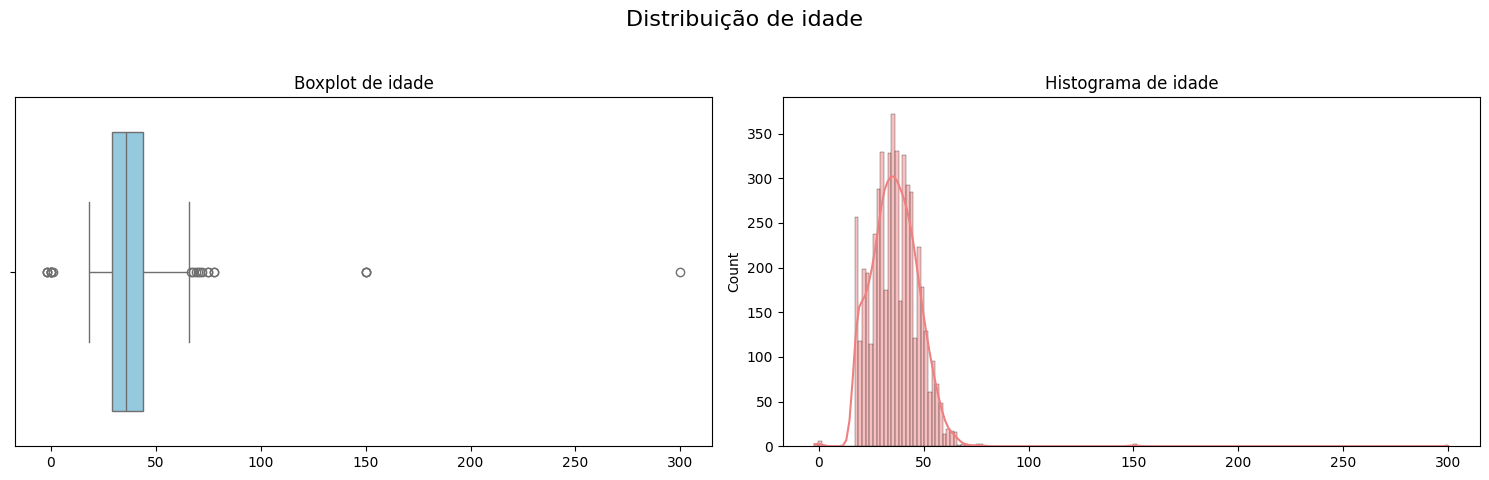

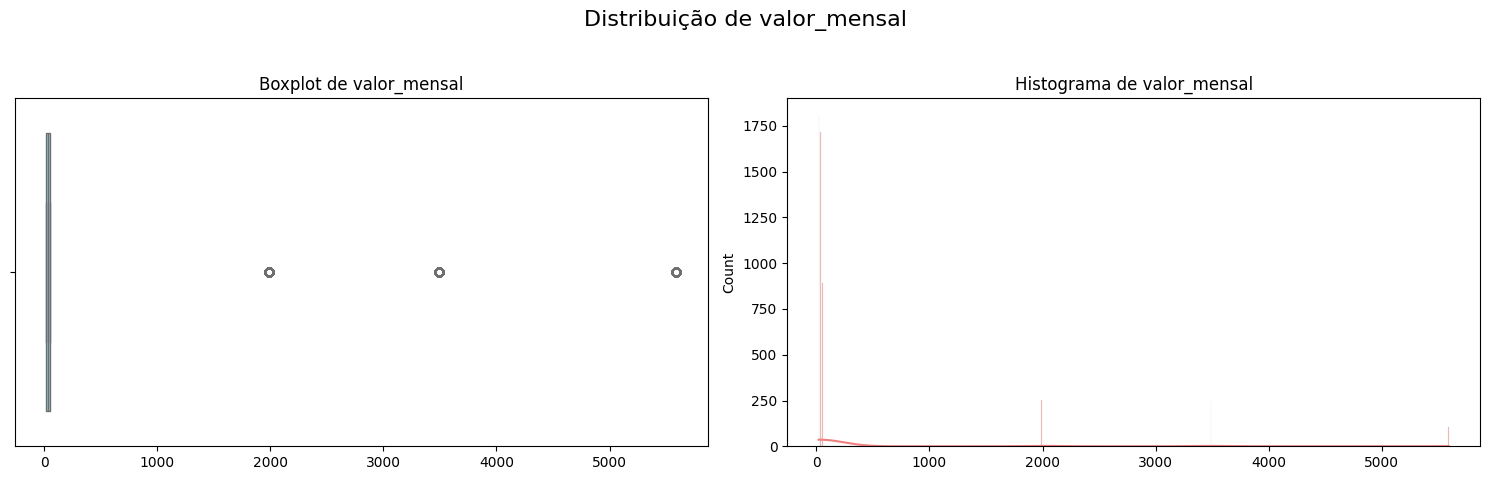

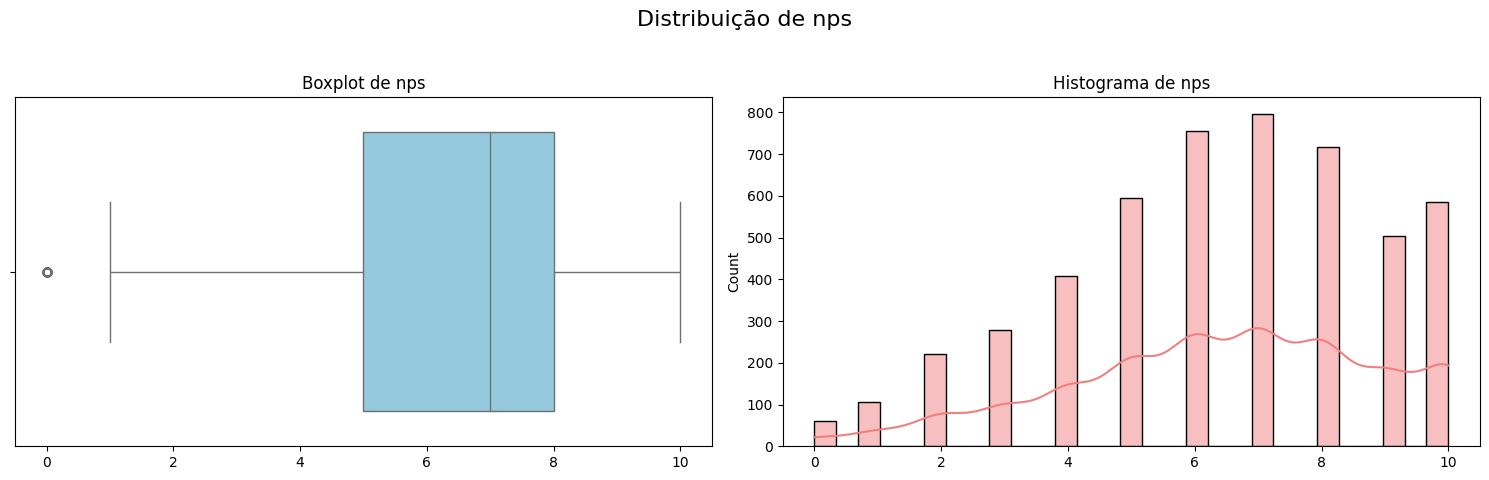

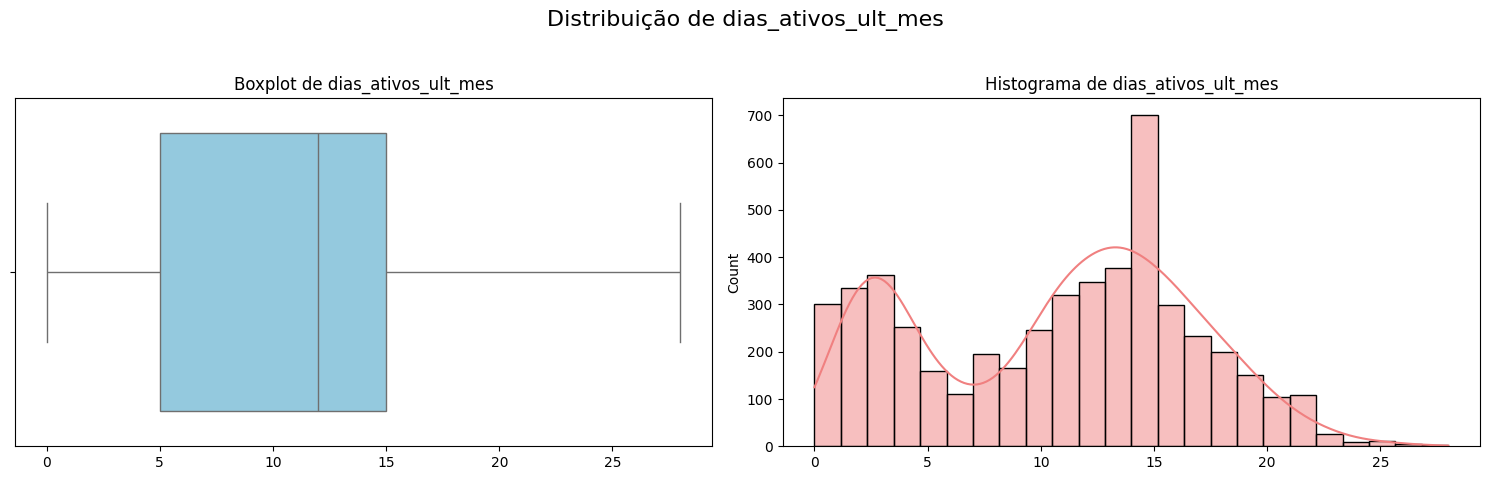

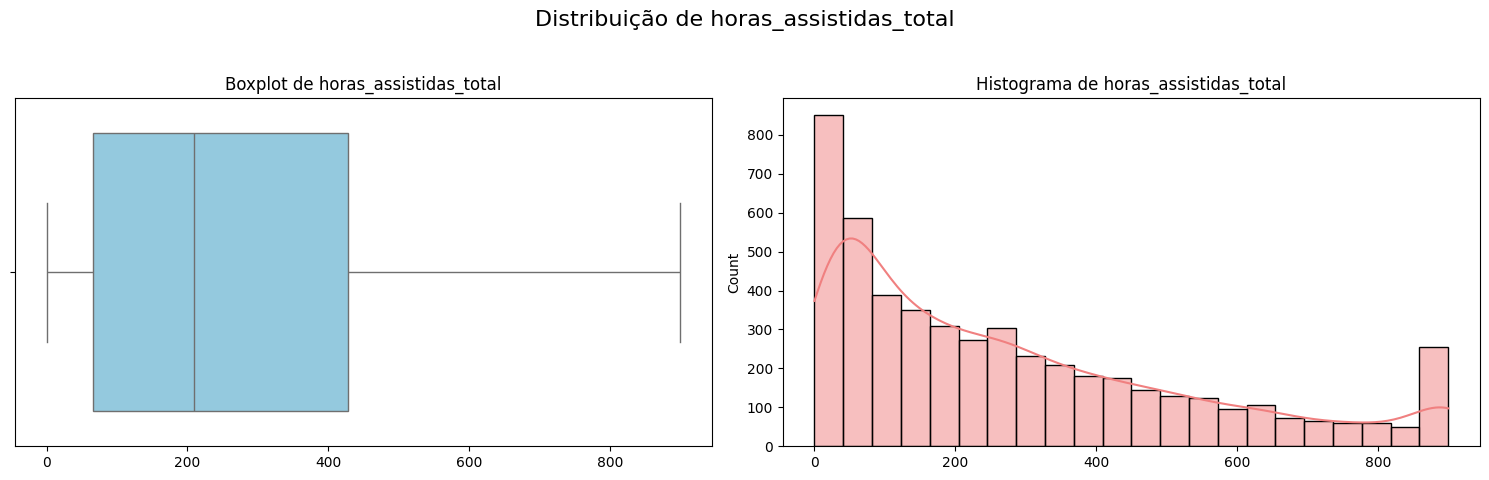

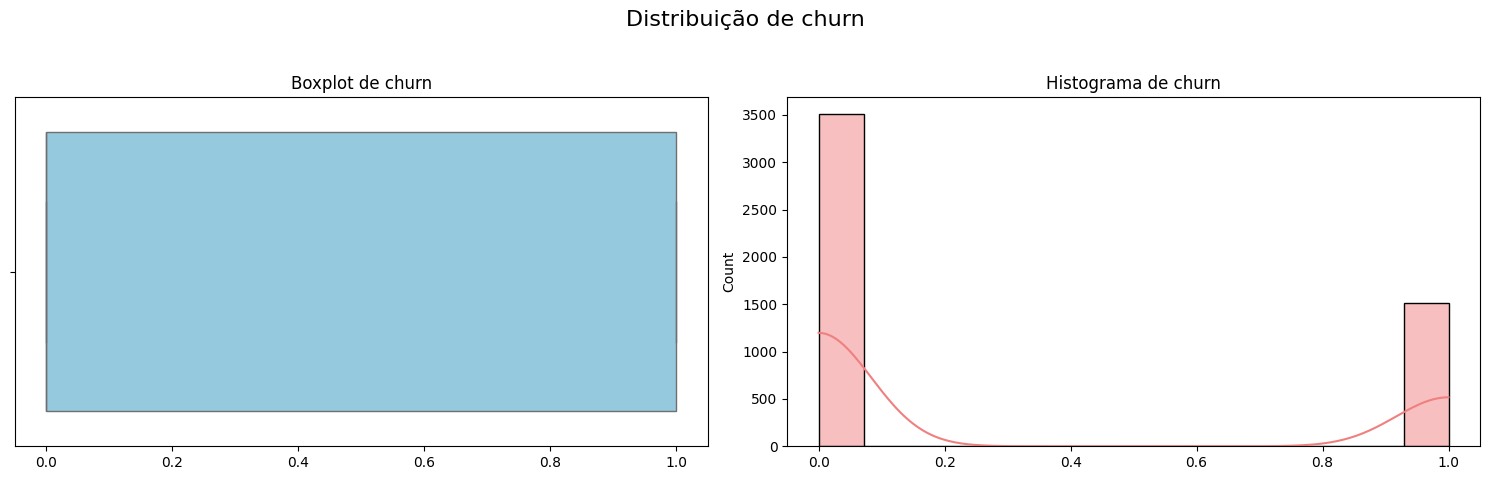

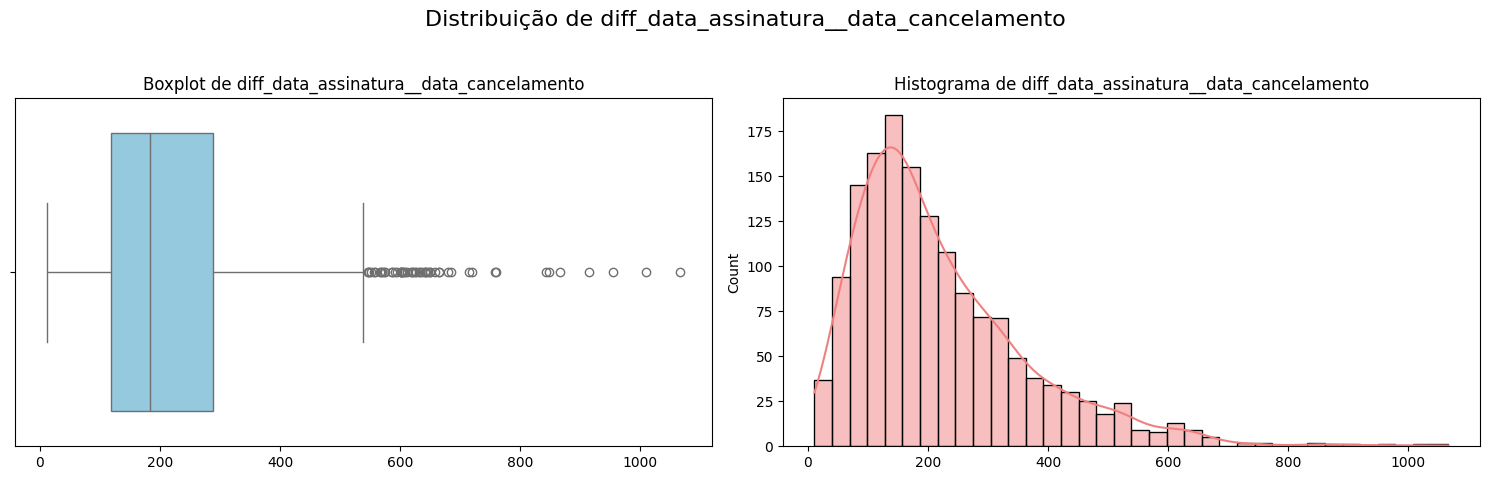

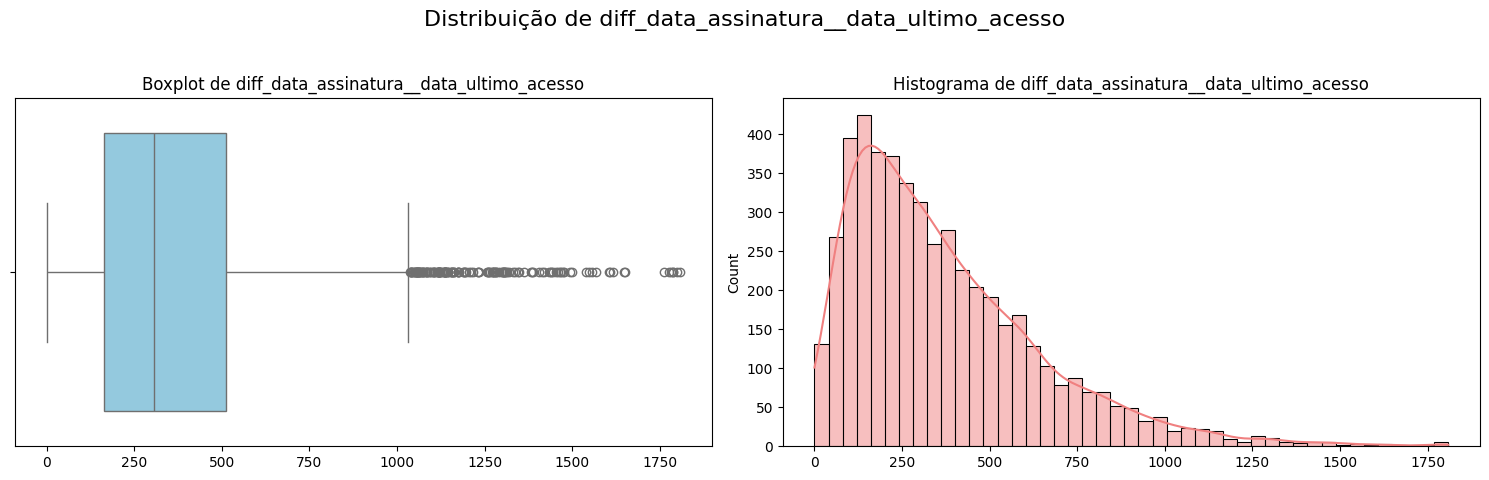

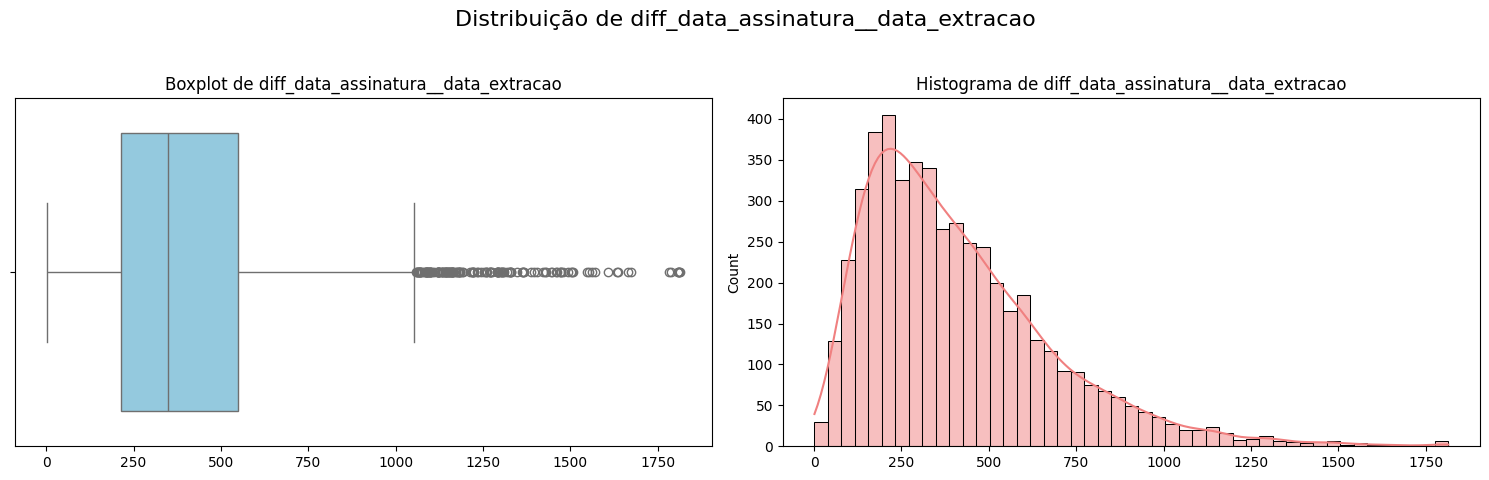

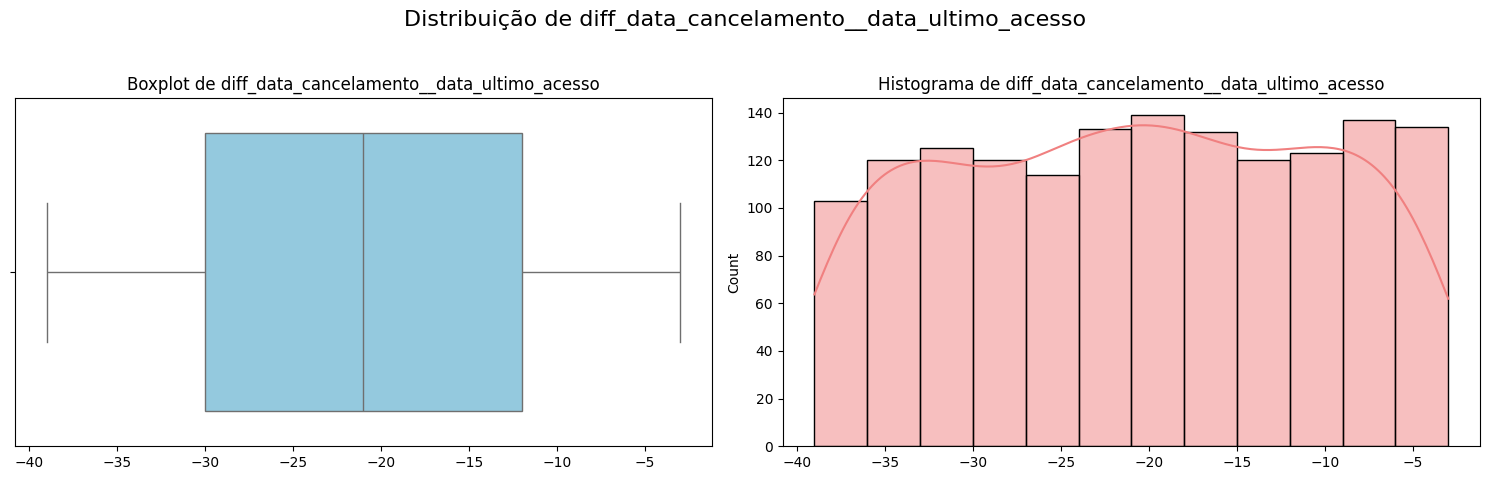

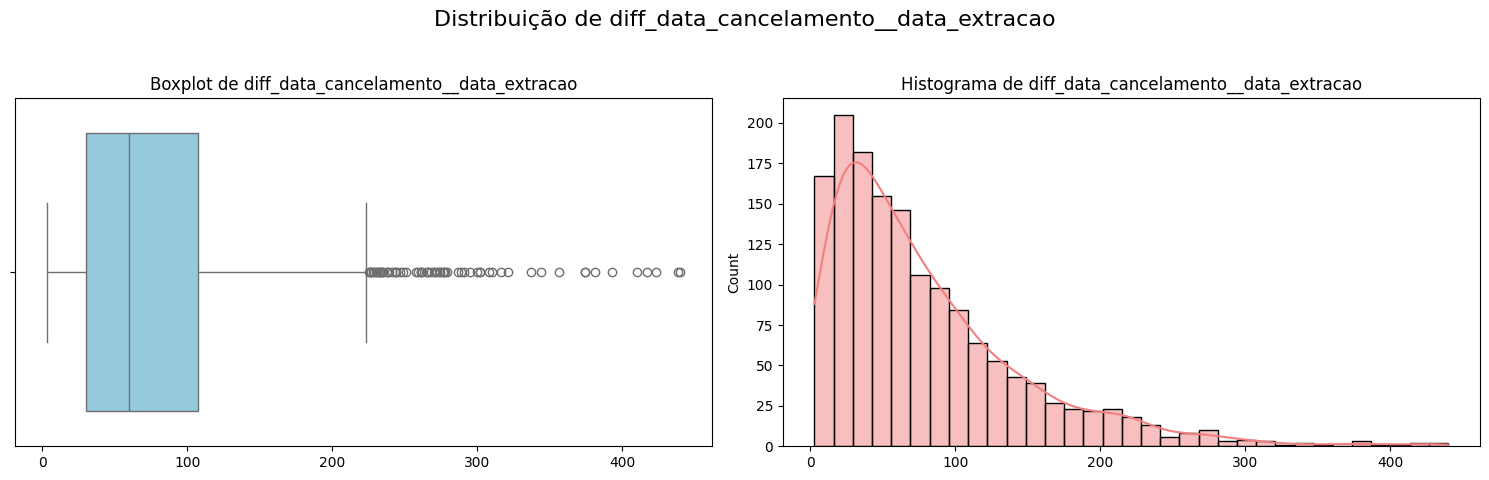

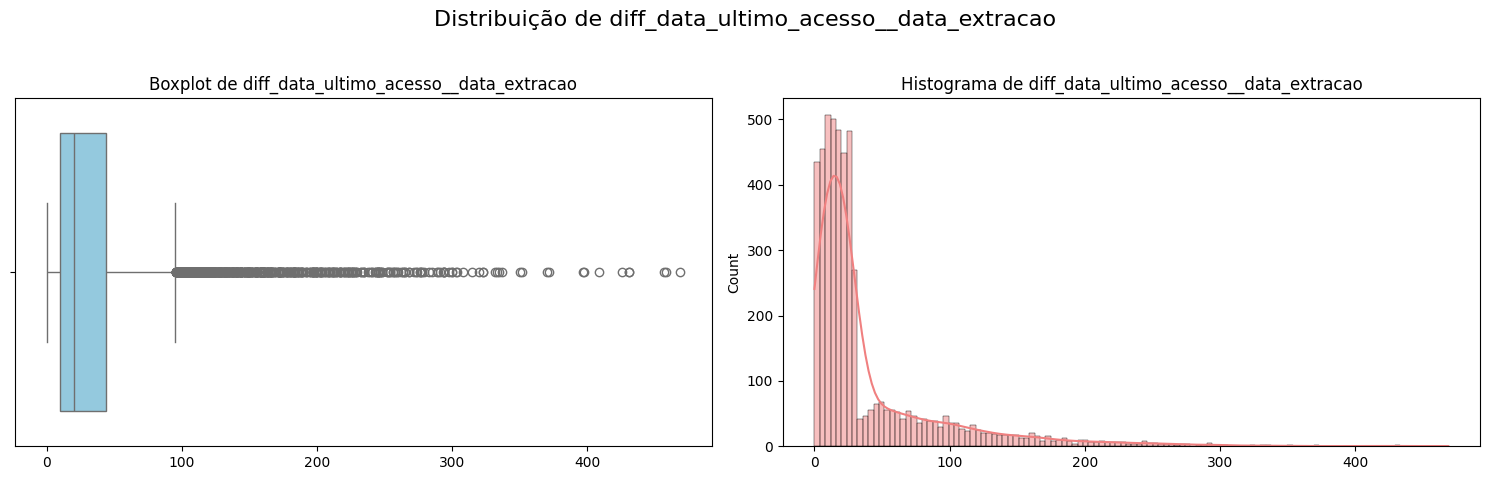

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar colunas numéricas, excluindo 'cliente_id'
# Usaremos df_filtrado para as visualizações
numerical_cols_for_plot = df_filtrado.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'cliente_id' in numerical_cols_for_plot:
    numerical_cols_for_plot.remove('cliente_id')

print(f"Gerando boxplots e histogramas para as seguintes colunas numéricas: {numerical_cols_for_plot}")

for col in numerical_cols_for_plot:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Distribuição de {col}', fontsize=16)

    # Boxplot
    sns.boxplot(x=df_filtrado[col], ax=axes[0], color='skyblue')
    axes[0].set_title(f'Boxplot de {col}')
    axes[0].set_xlabel('') # Remove x-label to avoid redundancy with suptitle

    # Histograma
    sns.histplot(df_filtrado[col].dropna(), kde=True, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Histograma de {col}')
    axes[1].set_xlabel('') # Remove x-label to avoid redundancy with suptitle

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para evitar sobreposição de títulos
    plt.show()

In [67]:
# Filtrar o DataFrame df_filtrado para remover linhas onde a idade é menor que 18 ou maior que 90
initial_rows_filtered = len(df_filtrado)
df_filtrado = df_filtrado[(df_filtrado['idade'] >= 18) & (df_filtrado['idade'] <= 90)].copy()
final_rows_filtered = len(df_filtrado)

print(f"Linhas em df_filtrado antes do filtro de idade: {initial_rows_filtered}")
print(f"Linhas em df_filtrado após o filtro de idade: {final_rows_filtered}")
print(f"Foram removidas {initial_rows_filtered - final_rows_filtered} linhas por idade fora do intervalo [18, 90].")

print("\nPrimeiras 5 linhas do DataFrame df_filtrado após o filtro de idade:")
display(df_filtrado.head())

Linhas em df_filtrado antes do filtro de idade: 5024
Linhas em df_filtrado após o filtro de idade: 5011
Foram removidas 13 linhas por idade fora do intervalo [18, 90].

Primeiras 5 linhas do DataFrame df_filtrado após o filtro de idade:


,cliente_id,idade,plano,ciclo,valor_mensal,regiao,canal_aquisicao,nps,data_assinatura,data_cancelamento,...,dias_ativos_ult_mes,horas_assistidas_total,motivo_cancelamento,churn,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acesso,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso__data_extracao
0,5746,36,BASICO,Anual,19.9,Sudeste,Indicacao,6,2023-04-11,NaT,...,15,276.0,NaN,0,NaN,293.0,295,NaN,NaN,2.0
1,4100,48,Padrão,Mensal,34.9,Sudeste,orgânico,8,2022-06-02,NaT,...,14,394.9,NaN,0,NaN,607.0,608,NaN,NaN,1.0
2,4690,48,Premium,Mensal,55.9,Nordeste,orgânico,4,2021-03-20,2022-11-17,...,5,257.0,PREÇO,1,607.0,590.0,1047,-17.0,440.0,457.0
3,3454,46,BASICO,Anual,1990.0,Sul,Google,10,2023-04-02,NaT,...,19,385.0,NaN,0,NaN,286.0,304,NaN,NaN,18.0
4,1437,46,Basico,Mensal,19.9,Norte,indicação,8,2023-04-21,NaT,...,11,205.3,NaN,0,NaN,270.0,285,NaN,NaN,15.0


In [68]:
# Filtrar df_filtrado para mostrar linhas onde 'valor_mensal' é maior que 1000
print("Linhas onde 'valor_mensal' é maior que 1000:")
display(df_filtrado[df_filtrado['valor_mensal'] > 1000])

Linhas onde 'valor_mensal' é maior que 1000:


,cliente_id,idade,plano,ciclo,valor_mensal,regiao,canal_aquisicao,nps,data_assinatura,data_cancelamento,...,dias_ativos_ult_mes,horas_assistidas_total,motivo_cancelamento,churn,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acesso,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso__data_extracao
3,3454,46,BASICO,Anual,1990.0,Sul,Google,10,2023-04-02,NaT,...,19,385.0,NaN,0,NaN,286.0,304,NaN,NaN,18.0
14,5581,18,Padrao,Mensal,3490.0,Sudeste,orgânico,7,2023-07-22,NaT,...,15,160.7,NaN,0,NaN,189.0,193,NaN,NaN,4.0
29,5979,31,Padrão,Mensal,3490.0,Sudeste,Instagram,10,2023-08-22,NaT,...,14,117.2,NaN,0,NaN,134.0,162,NaN,NaN,28.0
34,1433,56,Padrão,Anual,3490.0,NaN,orgânico,9,2023-04-14,NaT,...,11,180.4,NaN,0,NaN,283.0,292,NaN,NaN,9.0
42,4776,61,básico,Anual,1990.0,Sudeste,orgânico,4,2023-10-01,2023-12-15,...,6,47.8,problema tecnico,1,75.0,55.0,122,-20.0,47.0,67.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4979,4984,30,Padrao,Anual,3490.0,Sudeste,indicação,7,2020-12-01,NaT,...,20,900.0,NaN,0,NaN,1138.0,1156,NaN,NaN,18.0
4991,2396,23,padrão,Anual,3490.0,Nordeste,Organico,8,2021-04-14,NaT,...,18,900.0,NaN,0,NaN,1017.0,1022,NaN,NaN,5.0
5000,5926,37,Padrão,Anual,3490.0,Centro-Oeste,orgânico,10,2022-12-01,NaT,...,9,243.6,NaN,0,NaN,402.0,426,NaN,NaN,24.0
5006,4388,18,básico,Anual,1990.0,Nordeste,IG,9,2023-05-03,NaT,...,11,160.6,NaN,0,NaN,251.0,273,NaN,NaN,22.0


In [69]:
# Contar os valores distintos da coluna 'valor_mensal' em df_filtrado
distinct_valor_mensal_count = df_filtrado['valor_mensal'].nunique()

print(f"Número de valores distintos na coluna 'valor_mensal': {distinct_valor_mensal_count}")

Número de valores distintos na coluna 'valor_mensal': 6


In [70]:
# Contar os valores únicos e suas frequências na coluna 'valor_mensal'
print("Valores únicos e suas contagens na coluna 'valor_mensal':")
display(df_filtrado['valor_mensal'].value_counts())

Valores únicos e suas contagens na coluna 'valor_mensal':


,count
valor_mensal,
19.9,1806
34.9,1712
55.9,891
1990.0,252
3490.0,246
5590.0,104


In [71]:
# Dividir por 100 os valores da coluna 'valor_mensal' que são maiores que 1900
print("Valores de 'valor_mensal' antes da divisão:")
display(df_filtrado[df_filtrado['valor_mensal'] > 1900][['valor_mensal']].head())

df_filtrado.loc[df_filtrado['valor_mensal'] > 1900, 'valor_mensal'] = df_filtrado['valor_mensal'] / 100

print("\nPrimeiras 5 linhas do DataFrame df_filtrado após a divisão (onde aplicável):")
display(df_filtrado.head())

print("\nValores de 'valor_mensal' após a divisão (exibindo os modificados):")
display(df_filtrado[df_filtrado['valor_mensal'] > 19][['valor_mensal']].head()) # Assuming 19 is a threshold to show modified high values

Valores de 'valor_mensal' antes da divisão:


,valor_mensal
3,1990.0
14,3490.0
29,3490.0
34,3490.0
42,1990.0



Primeiras 5 linhas do DataFrame df_filtrado após a divisão (onde aplicável):


,cliente_id,idade,plano,ciclo,valor_mensal,regiao,canal_aquisicao,nps,data_assinatura,data_cancelamento,...,dias_ativos_ult_mes,horas_assistidas_total,motivo_cancelamento,churn,diff_data_assinatura__data_cancelamento,diff_data_assinatura__data_ultimo_acesso,diff_data_assinatura__data_extracao,diff_data_cancelamento__data_ultimo_acesso,diff_data_cancelamento__data_extracao,diff_data_ultimo_acesso__data_extracao
0,5746,36,BASICO,Anual,19.9,Sudeste,Indicacao,6,2023-04-11,NaT,...,15,276.0,NaN,0,NaN,293.0,295,NaN,NaN,2.0
1,4100,48,Padrão,Mensal,34.9,Sudeste,orgânico,8,2022-06-02,NaT,...,14,394.9,NaN,0,NaN,607.0,608,NaN,NaN,1.0
2,4690,48,Premium,Mensal,55.9,Nordeste,orgânico,4,2021-03-20,2022-11-17,...,5,257.0,PREÇO,1,607.0,590.0,1047,-17.0,440.0,457.0
3,3454,46,BASICO,Anual,19.9,Sul,Google,10,2023-04-02,NaT,...,19,385.0,NaN,0,NaN,286.0,304,NaN,NaN,18.0
4,1437,46,Basico,Mensal,19.9,Norte,indicação,8,2023-04-21,NaT,...,11,205.3,NaN,0,NaN,270.0,285,NaN,NaN,15.0



Valores de 'valor_mensal' após a divisão (exibindo os modificados):


,valor_mensal
0,19.9
1,34.9
2,55.9
3,19.9
4,19.9


In [72]:
# Contar os valores únicos e suas frequências na coluna 'valor_mensal'
print("Valores únicos e suas contagens na coluna 'valor_mensal':")
display(df_filtrado['valor_mensal'].value_counts())

Valores únicos e suas contagens na coluna 'valor_mensal':


,count
valor_mensal,
19.9,2058
34.9,1958
55.9,995


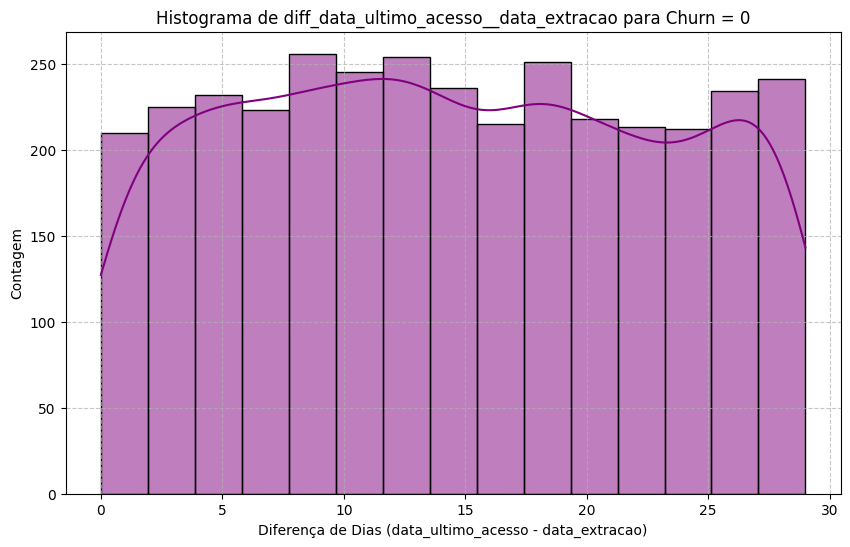

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar o DataFrame para churn == 0
df_churn_0 = df_filtrado[df_filtrado['churn'] == 0]

# Criar o histograma para 'diff_data_ultimo_acesso__data_extracao' onde churn é 0
plt.figure(figsize=(10, 6))
sns.histplot(df_churn_0['diff_data_ultimo_acesso__data_extracao'].dropna(), kde=True, color='purple')
plt.title('Histograma de diff_data_ultimo_acesso__data_extracao para Churn = 0')
plt.xlabel('Diferença de Dias (data_ultimo_acesso - data_extracao)')
plt.ylabel('Contagem')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()